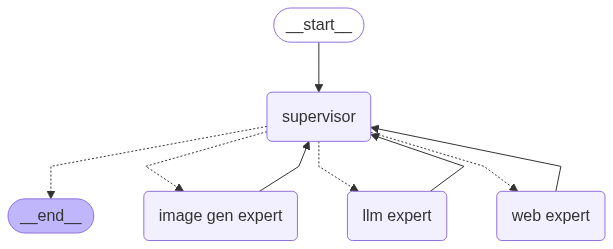

{'messages': [HumanMessage(content='Give me image of cat and dog?', additional_kwargs={}, response_metadata={}, id='a57324b6-8c3d-48f2-b36e-76a9d5c14cf9'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'transfer_to_image_gen_expert', 'arguments': '{}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='supervisor', id='run--68f941d6-f04e-4a3b-b0e9-aaf28be043ce-0', tool_calls=[{'name': 'transfer_to_image_gen_expert', 'args': {}, 'id': '8ae180af-1338-4fa5-be68-0dbdbb292a81', 'type': 'tool_call'}], usage_metadata={'input_tokens': 58, 'output_tokens': 9, 'total_tokens': 67, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content='Successfully transferred to image gen expert', name='transfer_to_image_gen_expert', id='291fef15-a1c0-41ba-9596-97a13553631f', tool_call_id='8ae180af-1338-4fa5-be68-0dbdbb292a81'),
        

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langgraph.checkpoint.memory import InMemorySaver
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from IPython.display import display, Image
import base64, os
from dotenv import load_dotenv

load_dotenv()

# Set up memory store and models
checkpointer = InMemorySaver()
store = InMemorySaver()

llm = ChatGoogleGenerativeAI(model=os.getenv("GOOGLE_MODEL"))
image_llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-preview-image-generation")

# Web search tool
@tool
def tavily_search_tool_func(query: str) -> str:
    """Search the web for up-to-date information."""
    return TavilySearch(max_results=5, topic="general").invoke(query)

web_search_agent = create_react_agent(model=llm, tools=[tavily_search_tool_func], name="web expert")

# LLM query tool
@tool
def llm_based_Search_func(query: str) -> str:
    """Answer general knowledge queries using LLM."""
    return llm.invoke(query).content

llm_search_agent = create_react_agent(model=llm, tools=[llm_based_Search_func], name="llm expert")

# Image generation tool
@tool
def image_gen_func(query: str) -> str:
    """Generate an image based on the description."""
    enhanced_query = (
        f"Create an image illustrating the following concept:\n{query}\n\n"
        "Only use English for any text in the image, and avoid unnecessary words."
    )
    response = image_llm.invoke(
        [HumanMessage(content=enhanced_query)],
        generation_config=dict(response_modalities=["TEXT", "IMAGE"])
    )

    # Extract image from response
    image_block = next(
        (block for block in response.content if isinstance(block, dict) and "image_url" in block),
        None
    )
    
    if not image_block:
        return "No image was generated."

    image_url = image_block["image_url"].get("url", "")
    if "base64" in image_url:
        base64_data = image_url.split(",")[-1]
        try:
            display(Image(data=base64.b64decode(base64_data), width=300))
        except Exception as e:
            return f"Failed to render image: {e}"
    else:
        return f"Image URL: {image_url}"  # fallback for URL-based image (if any)

    return "Image generated successfully."

image_gen_agent = create_react_agent(model=llm, tools=[image_gen_func], name="image gen expert")

# Supervisor setup
workflow = create_supervisor(
    [web_search_agent, llm_search_agent, image_gen_agent],
    model=llm,
    output_mode="full_history"
)

app = workflow.compile()

# Show graph
display(Image(app.get_graph().draw_mermaid_png()))

# Invoke example
config = {"configurable": {"thread_id": "1"}}
result = app.invoke({
    "messages": [{"role": "user", "content": "Give me image of cat and dog?"}]
}, config=config)

from pprint import pprint
pprint(result)
print("\nFinal message content:")
print(result["messages"][-1].content)

# Streaming example
print("\nStreaming another query:")
for chunk in app.stream({"messages": [{"role": "user", "content": "What is AI?"}]}, config=config):
    print(chunk)
    print("\n")
